# T02 - EDA Millas por Galón (R)
Dataset: `Auto` del paquete ISLR2. No se le hizo preprocesamiento, solo se convirtió `origin` a factor porque viene como 1, 2 y 3.

**Variable elegida:** `mpg`

In [ ]:
library(ISLR2)
library(ggplot2)
library(gridExtra)
data("Auto")

Auto$origin <- factor(Auto$origin, levels = 1:3, labels = c("usa", "europe", "japan"))

options(repr.plot.width = 9, repr.plot.height = 5) 
head(Auto)

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<fct>,<fct>
1,18,8,307,130,3504,12.0,70,usa,chevrolet chevelle malibu
2,15,8,350,165,3693,11.5,70,usa,buick skylark 320
3,18,8,318,150,3436,11.0,70,usa,plymouth satellite
4,16,8,304,150,3433,12.0,70,usa,amc rebel sst
5,17,8,302,140,3449,10.5,70,usa,ford torino
6,15,8,429,198,4341,10.0,70,usa,ford galaxie 500


## Reconocimiento del dataset

In [ ]:
cat("Filas y columnas:", dim(Auto), "\n")
cat("Variables numericas:", names(Auto)[sapply(Auto, is.numeric)], "\n")
cat("\nNulos por columna:\n")
print(colSums(is.na(Auto)))

Filas y columnas: 392 9 


Variables numericas: mpg cylinders displacement horsepower weight acceleration year 



Nulos por columna:


         mpg    cylinders displacement   horsepower       weight acceleration 
           0            0            0            0            0            0 
        year       origin         name 
           0            0            0 


| Pregunta | Respuesta |
|---|---|
| Cuantas filas y columnas tiene el dataset? | 392 filas y 9 columnas |
| Que variables numericas contiene? | mpg, cylinders, displacement, horsepower, weight, acceleration y year |
| Existen valores nulos? En que columnas? | No hay nulos en ninguna columna |
| Cual es la variable que analizaremos? | mpg |

## Paso 1: Seleccion de la variable
**Variable elegida: mpg (rendimiento de combustible)**

## Paso 2: Medidas descriptivas previas

In [ ]:
x <- Auto$mpg   # variable que vamos a analizar

medidas <- data.frame(
  Medida = c("n", "Minimo", "Maximo", "Rango", "Media", "Mediana", "Desv. estandar", "CV (%)"),
  Valor  = round(c(length(x), min(x), max(x), max(x) - min(x),
                   mean(x), median(x), sd(x), sd(x) / mean(x) * 100), 2)
)
medidas

Medida,Valor
<chr>,<dbl>
n,392.00
Minimo,9.00
Maximo,46.60
Rango,37.60
Media,23.45
Mediana,22.75
Desv. estandar,7.81
CV (%),33.29


**Interpretacion:** El dataset tiene 392 autos y su rendimiento va de 9 a 46.6 millas por galon, o sea que el mejor auto rinde mas de 4 veces lo que el peor. La media es 23.45 mpg y la mediana es 22.75 mpg, entonces la mitad de los autos rinde menos de 22.75 millas por cada galon de gasolina. La desviacion estandar es 7.81 y el coeficiente de variacion es 33.3 %, lo que significa que los datos estan bastante dispersos porque hay autos chicos que gastan poco y autos grandes que gastan mucho.

### Tabla de frecuencias
Usando la regla de Sturges: k = 1 + 3.322 * log10(392) = 9.6, entonces k = 10 intervalos. La amplitud es A = 37.6 / 10 = 3.76, que redondeo a 3.8.

In [ ]:
n <- length(x)
k <- ceiling(1 + 3.322 * log10(n))                  # numero de intervalos (Sturges)
A <- ceiling((max(x) - min(x)) / k * 10) / 10       # amplitud
limites <- round(min(x) + A * (0:k), 1)             # limites de los intervalos

# frecuencia absoluta de cada intervalo
f <- as.vector(table(cut(x, breaks = limites, right = FALSE, include.lowest = TRUE)))

tabla <- data.frame(
  Intervalo = paste0("[", limites[-(k + 1)], ", ", limites[-1], ")"),
  f      = f,                                # frecuencia absoluta
  fa     = cumsum(f),                        # frecuencia acumulada
  fr_pct = round(f / n * 100, 2),            # porcentaje
  Fa_pct = round(cumsum(f) / n * 100, 2)     # porcentaje acumulado
)
cat("k =", k, "  A =", A, "\n")
tabla

k = 10   A = 3.8 


Intervalo,f,fa,fr_pct,Fa_pct
<chr>,<int>,<int>,<dbl>,<dbl>
"[9, 12.8)",13,13,3.32,3.32
"[12.8, 16.6)",78,91,19.90,23.21
"[16.6, 20.4)",74,165,18.88,42.09
"[20.4, 24.2)",57,222,14.54,56.63
"[24.2, 28)",54,276,13.78,70.41
"[28, 31.8)",48,324,12.24,82.65
"[31.8, 35.6)",36,360,9.18,91.84
"[35.6, 39.4)",23,383,5.87,97.70
"[39.4, 43.2)",4,387,1.02,98.72


## Paso 3: Visualizacion

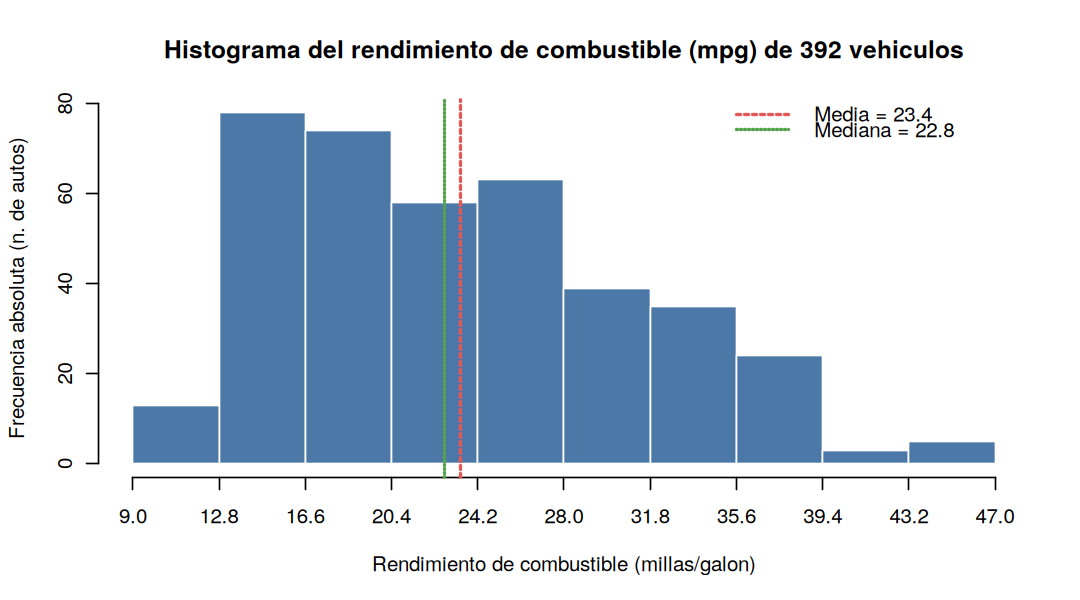

In [ ]:
# Histograma con la media y la mediana
hist(x, breaks = limites, col = "#4C78A8", border = "white", xaxt = "n",
     main = "Histograma del rendimiento de combustible (mpg) de 392 vehiculos",
     xlab = "Rendimiento de combustible (millas/galon)",
     ylab = "Frecuencia absoluta (n. de autos)")
axis(1, at = limites)
abline(v = mean(x),   col = "#E45756", lty = 2, lwd = 2)
abline(v = median(x), col = "#54A24B", lty = 3, lwd = 2)
legend("topright", bty = "n", lwd = 2, lty = c(2, 3), col = c("#E45756", "#54A24B"),
       legend = c(paste0("Media = ", round(mean(x), 1)),
                  paste0("Mediana = ", round(median(x), 1))))

Asimetria: 0.46 


Atipicos:  


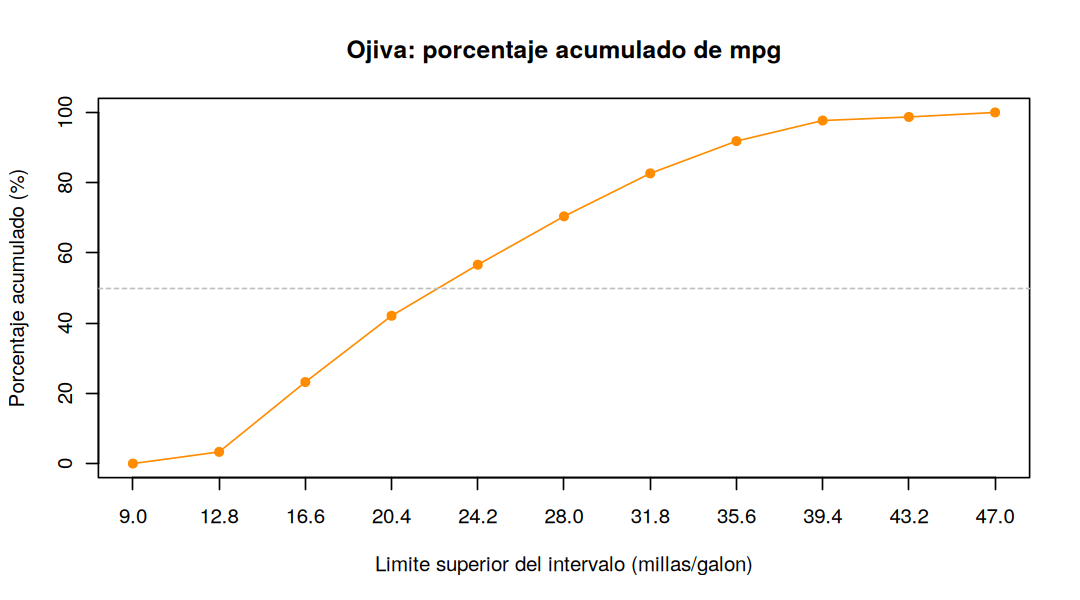

In [ ]:
# Ojiva: porcentaje acumulado
plot(limites, c(0, tabla$Fa_pct), type = "o", pch = 16, col = "darkorange",
     xaxt = "n", ylim = c(0, 100),
     main = "Ojiva: porcentaje acumulado de mpg",
     xlab = "Limite superior del intervalo (millas/galon)",
     ylab = "Porcentaje acumulado (%)")
axis(1, at = limites)
abline(h = 50, lty = 2, col = "gray")

# asimetria y atipicos
cat("Asimetria:", round(sum((x - mean(x))^3) / n / (sum((x - mean(x))^2) / n)^1.5, 2), "\n")
cat("Atipicos:", boxplot.stats(x)$out, "\n")

**Analisis de la forma de la distribucion**

- **Es simetrica o sesgada?** Es sesgada a la derecha. La asimetria da 0.46 y la media (23.45) es un poco mayor que la mediana (22.75).
- **Hacia que lado se concentra la mayor frecuencia?** Hacia los valores bajos. El intervalo con mas autos es [12.8, 16.6) con 78 autos y despues las frecuencias van bajando.
- **Hay valores atipicos visibles?** No salio ninguno con el criterio de 1.5 por el rango intercuartil. El valor mas alto es 46.6, pero esta dentro del limite (47.0), asi que es un auto muy eficiente pero normal.

## Paso 4: Interpretacion de resultados

**Contexto de la variable.** La variable mpg mide el rendimiento de combustible, o sea cuantas millas recorre un auto con un galon. Entre mas alto sea el valor, mas eficiente es el auto. Se analizaron 392 autos de los años 1970 a 1982.

**Tendencia central.** La media es 23.45 y la mediana es 22.75, son muy parecidas pero la media es un poco mas grande. Esto pasa porque hay unos pocos autos muy eficientes (mas de 35 mpg) que suben la media, mientras que la mediana no se afecta por esos valores.

**Dispersion.** La desviacion estandar es 7.81 y el CV es 33.3 %, es decir que la desviacion es como un tercio de la media. Esto quiere decir que hay bastante variabilidad, no hay un auto tipico porque se mezclan autos de distintos tamaños y motores.

**Distribucion de frecuencias.** El intervalo con mas observaciones es [12.8, 16.6) con 78 autos, que es el 19.90 % del total. Le sigue [16.6, 20.4) con 74 autos (18.88 %). Entre los dos juntan casi el 39 % de los autos.

**Acumulados.** En el tercer intervalo, la frecuencia acumulada es fa = 165. Esto significa que 165 autos (42.09 %) rinden menos de 20.4 mpg. Ademas, como el 70 % de los autos rinde menos de 28 mpg, la mayoria no es muy eficiente.

**Conclusion general.** Los autos del dataset tienen en su mayoria un rendimiento bajo o medio, y pocos son muy eficientes, por eso la distribucion se sesga a la derecha. Como hay tanta variabilidad, el rendimiento seguramente depende de otras variables como los cilindros, el peso, el origen y el año, que se revisan en el Paso 6.

## Paso 5: Preguntas de reflexion

**1. Que informacion aporta la ojiva que no aporta el histograma?**
El histograma solo muestra cuantos autos hay en cada intervalo, o sea la forma de la distribucion. La ojiva muestra los datos acumulados, entonces se puede ver que porcentaje de autos esta por debajo de cierto valor (por ejemplo 42 % rinde menos de 20.4 mpg) y se puede calcular la mediana de forma grafica, que es donde la linea llega al 50 %. Tambien sirve para comparar varios grupos en un mismo grafico.

**2. Como compararia 4 vs 8 cilindros usando tablas de frecuencia?**
Haria una tabla de frecuencias para cada grupo con los mismos intervalos. Compararia los porcentajes y no las frecuencias absolutas, porque los grupos tienen tamaños distintos (199 autos de 4 cilindros y 103 de 8). Despues miraria en que intervalo se concentra cada grupo y los porcentajes acumulados. Se esperaria que los de 8 cilindros esten en los intervalos bajos y los de 4 en los intervalos altos.

## Paso 6: Analisis comparativo
### Pregunta 1: mpg segun el numero de cilindros

cil,mpg
<fct>,"<dbl[,4]>"
3,"4, 20.25, 20.55, 2.56"
4,"199, 28.40, 29.28, 5.67"
5,"3, 25.40, 27.37, 8.23"
6,"83, 19.00, 19.97, 3.83"
8,"103, 14.00, 14.96, 2.84"


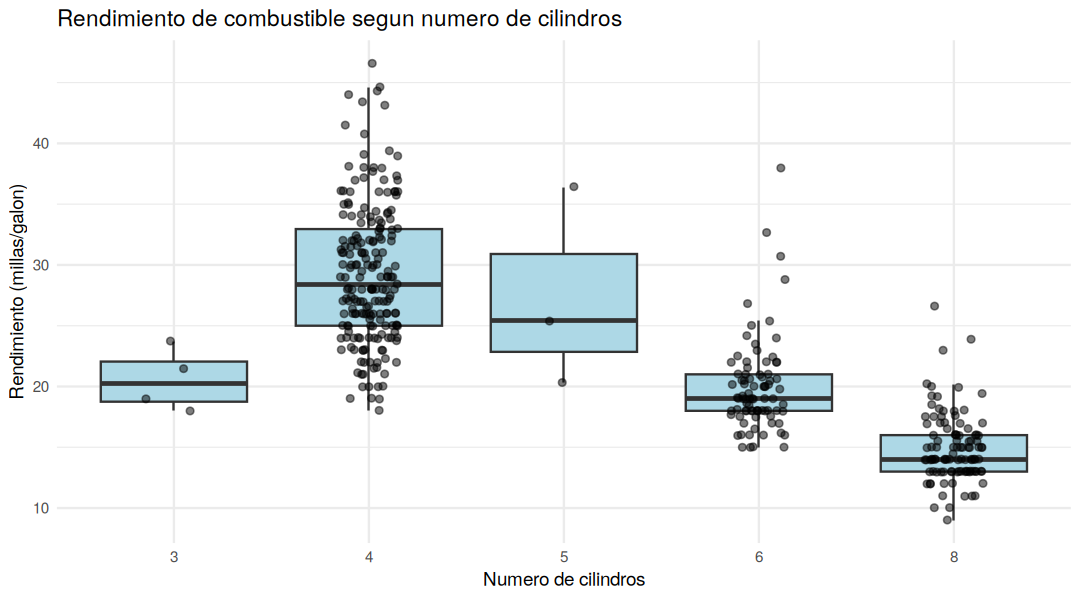

In [ ]:
Auto$cil <- factor(Auto$cylinders)   # cilindros como factor para el grafico

ggplot(Auto, aes(x = cil, y = mpg)) +
  geom_boxplot(fill = "lightblue", outlier.shape = NA) +
  geom_jitter(width = 0.15, alpha = 0.5, size = 1.5) +   # puntos de dispersion
  labs(title = "Rendimiento de combustible segun numero de cilindros",
       x = "Numero de cilindros", y = "Rendimiento (millas/galon)") +
  theme_minimal()

aggregate(mpg ~ cil, data = Auto,
          FUN = function(v) round(c(n = length(v), mediana = median(v),
                                    media = mean(v), sd = sd(v)), 2))

**Interpretacion tecnica:**

- **Como varia la mediana?** Baja cuando aumentan los cilindros: 4 cilindros tiene 28.4 mpg, 6 cilindros 19.0 y 8 cilindros 14.0. Los de 3 y 5 cilindros tienen muy pocos autos (4 y 3) asi que no se puede concluir mucho de ellos.
- **Que grupo tiene mas dispersion?** Entre los grupos grandes, el de 4 cilindros (desviacion 5.67). Puede ser porque en ese grupo hay desde autos muy chicos y eficientes hasta autos mas pesados. El de 8 cilindros es el mas parejo (desviacion 2.84) porque son todos autos grandes con consumo alto.
- **Hay solapamiento?** Las cajas de 4 y 8 cilindros no se tocan, o sea que hay una diferencia clara. Las de 4 y 6, y 6 y 8, se solapan muy poco. Estadisticamente esto sugiere que las medias de los grupos son diferentes.
- **Hipotesis para ANOVA:** H0: la media de mpg es igual para los autos de 4, 6 y 8 cilindros. H1: por lo menos un grupo tiene una media distinta.

### Pregunta 2: mpg segun el pais de origen

origin,mpg
<fct>,"<dbl[,4]>"
usa,"245, 20.03, 18.5, 6.44"
europe,"68, 27.60, 26.0, 6.58"
japan,"79, 30.45, 31.6, 6.09"


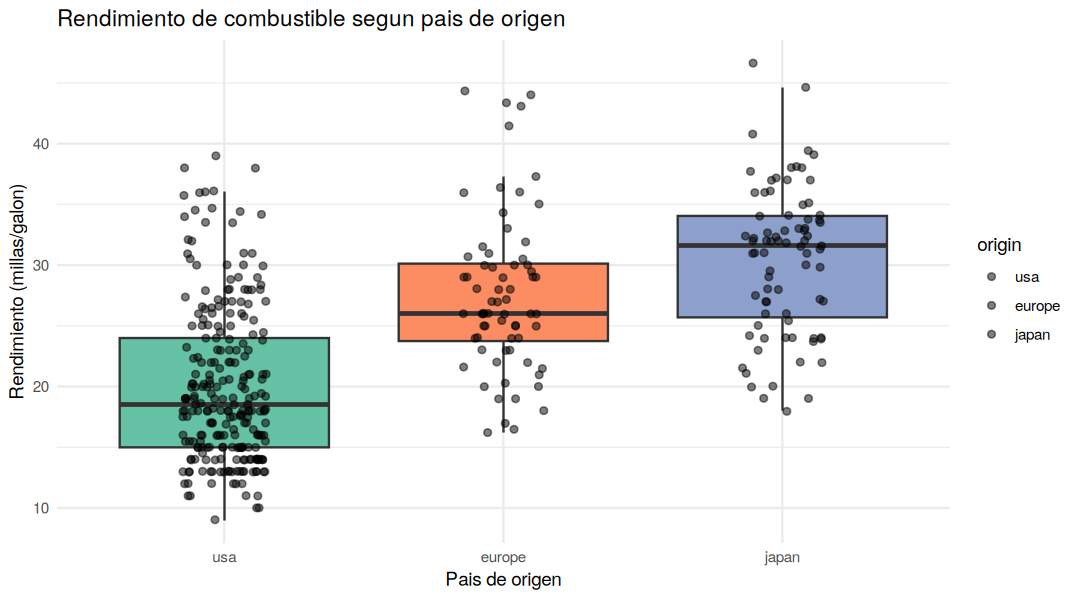

In [ ]:
ggplot(Auto, aes(x = origin, y = mpg, fill = origin)) +
  geom_boxplot(outlier.shape = NA, show.legend = FALSE) +
  geom_jitter(width = 0.15, alpha = 0.5, size = 1.5) +
  scale_fill_brewer(palette = "Set2") +
  labs(title = "Rendimiento de combustible segun pais de origen",
       x = "Pais de origen", y = "Rendimiento (millas/galon)") +
  theme_minimal()

aggregate(mpg ~ origin, data = Auto,
          FUN = function(v) round(c(n = length(v), media = mean(v),
                                    mediana = median(v), sd = sd(v)), 2))

**Interpretacion tecnica:**

- **Mejor y peor origen:** Japon tiene el mejor rendimiento promedio (30.45 mpg) y USA el peor (20.03 mpg). Europa queda en medio con 27.60.
- **Forma de las distribuciones:** no son iguales. USA y Europa estan sesgadas a la derecha (asimetria 0.84 y 0.77) y Japon es casi simetrica (0.01) y esta mas corrida hacia valores altos.
- **Igualdad de varianzas:** las desviaciones son parecidas (USA 6.44, Europa 6.58 y Japon 6.09) y las cajas tienen un tamaño similar, entonces los datos sugieren que las varianzas son iguales.
- **Variables de confusion:** el origen no explica todo por si solo. USA fabricaba muchos autos de 8 cilindros que son grandes y pesados, mientras que Japon y Europa tenian mas autos chicos de 4 cilindros. Por eso los cilindros, el peso, la cilindrada, la potencia y el año pueden estar confundiendo la comparacion.

### Pregunta 3: origen y cilindros sobre el rendimiento

origin,cil,mpg
<fct>,<fct>,"<dbl[,2]>"
japan,3,"4, 20.2"
usa,4,"69, 27.2"
europe,4,"61, 27.0"
japan,4,"69, 32.0"
europe,5,"3, 25.4"
usa,6,"73, 19.0"
europe,6,"4, 16.8"
japan,6,"6, 23.1"
usa,8,"103, 14.0"


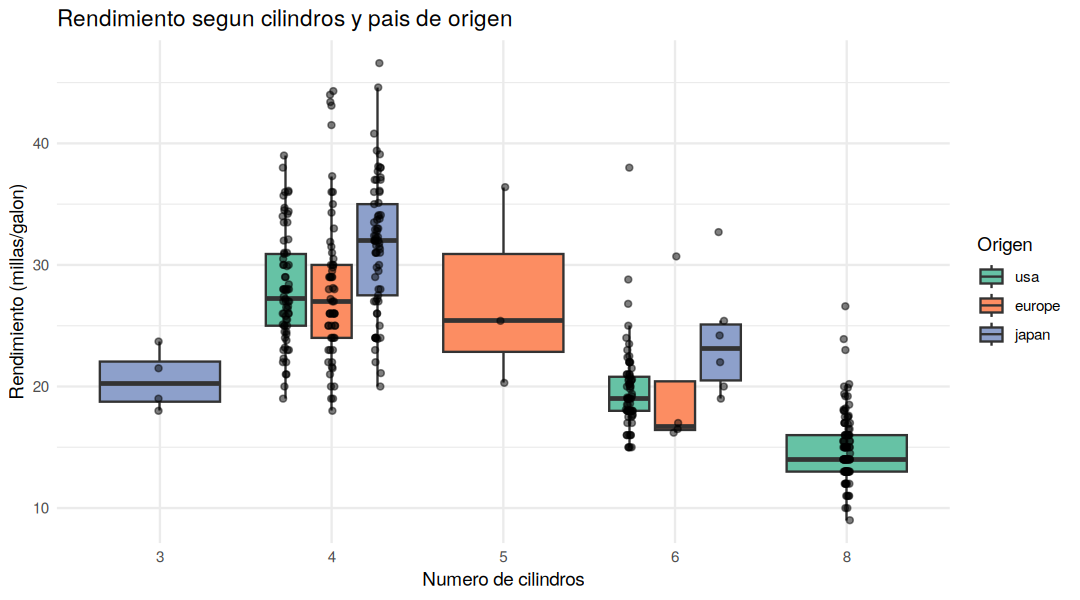

In [ ]:
ggplot(Auto, aes(x = cil, y = mpg, fill = origin)) +
  geom_boxplot(outlier.shape = NA, position = position_dodge(0.8), width = 0.7) +
  geom_point(aes(group = origin),
             position = position_jitterdodge(jitter.width = 0.1, dodge.width = 0.8),
             alpha = 0.5, size = 1.3, show.legend = FALSE) +
  scale_fill_brewer(palette = "Set2") +
  labs(title = "Rendimiento segun cilindros y pais de origen",
       x = "Numero de cilindros", y = "Rendimiento (millas/galon)", fill = "Origen") +
  theme_minimal()

aggregate(mpg ~ origin + cil, data = Auto,
          FUN = function(v) round(c(n = length(v), mediana = median(v)), 1))

**Interpretacion tecnica:**

- **El efecto de los cilindros es constante entre origenes?** El efecto va en la misma direccion en todos (mas cilindros, menos mpg), pero no es igual de fuerte. En USA la mediana baja de 27.2 a 19.0 y a 14.0 (4, 6 y 8 cilindros). En Japon baja de 32.0 a 23.1 (4 y 6 cilindros). En Europa baja de 27.0 a 16.8, aunque ese dato son solo 4 autos.
- **Algun origen se comporta diferente?** Si, Japon. Con 4 cilindros rinde mas (mediana 32.0) que USA (27.2) y Europa (27.0). Ademas solo USA tiene autos de 8 cilindros.
- **Ventajas del grafico:** deja ver dos variables al mismo tiempo y se puede separar el efecto del origen del efecto de los cilindros. Asi se nota que parte de la diferencia entre paises se debe a que fabricaban distintos tipos de motores. Hay que tener cuidado porque algunos grupos tienen muy pocos datos.

### Pregunta 4: composicion de cilindros y origenes por año

70   71   72   73   74   75   76   77   78   79   80   81   82 
17.7 21.1 18.7 17.1 22.8 20.3 21.6 23.4 24.1 25.1 33.8 30.2 32.0

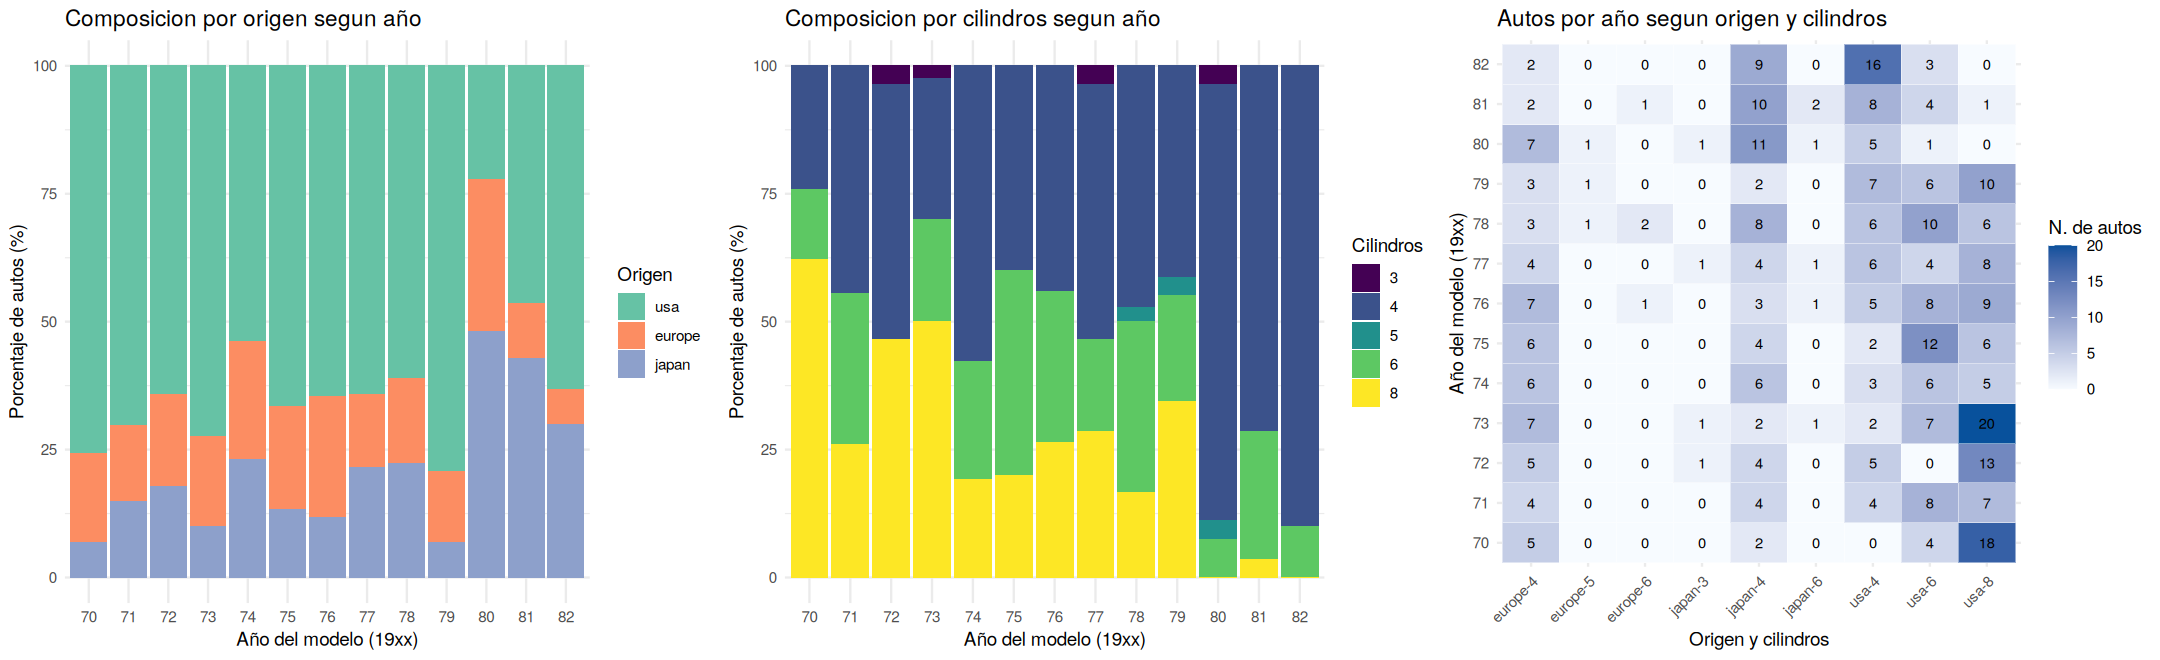

In [ ]:
options(repr.plot.width = 18, repr.plot.height = 5.5)   # grafico mas ancho

# tablas de porcentajes por año
d_origen <- as.data.frame(prop.table(table(year = Auto$year, origen = Auto$origin), 1) * 100)
d_cil    <- as.data.frame(prop.table(table(year = Auto$year, cilindros = Auto$cylinders), 1) * 100)
d_multi  <- as.data.frame(table(year = Auto$year, combo = paste(Auto$origin, Auto$cylinders, sep = "-")))

# grafico 1: composicion por origen
g1 <- ggplot(d_origen, aes(x = year, y = Freq, fill = origen)) +
  geom_col() + scale_fill_brewer(palette = "Set2") +
  labs(title = "Composicion por origen segun año", x = "Año del modelo (19xx)",
       y = "Porcentaje de autos (%)", fill = "Origen") +
  theme_minimal()

# grafico 2: composicion por cilindros
g2 <- ggplot(d_cil, aes(x = year, y = Freq, fill = cilindros)) +
  geom_col() + scale_fill_viridis_d() +
  labs(title = "Composicion por cilindros segun año", x = "Año del modelo (19xx)",
       y = "Porcentaje de autos (%)", fill = "Cilindros") +
  theme_minimal()

# grafico 3 (multivariado): mapa de calor año x origen x cilindros
g3 <- ggplot(d_multi, aes(x = combo, y = year, fill = Freq)) +
  geom_tile(color = "white") + geom_text(aes(label = Freq), size = 3) +
  scale_fill_gradient(low = "#F7FBFF", high = "#08519C") +
  labs(title = "Autos por año segun origen y cilindros", x = "Origen y cilindros",
       y = "Año del modelo (19xx)", fill = "N. de autos") +
  theme_minimal() + theme(axis.text.x = element_text(angle = 45, hjust = 1))

grid.arrange(g1, g2, g3, ncol = 3)

options(repr.plot.width = 9, repr.plot.height = 5)
round(tapply(Auto$mpg, Auto$year, mean), 1)   # mpg promedio por año

**Interpretacion tecnica:**

- **Como evoluciono la participacion de cada origen?** USA domino casi todo el periodo (entre 55 % y 80 % de los autos hasta 1979) pero en 1980 bajo mucho (6 de 27 autos). Europa se mantuvo bajo y estable (entre 7 % y 30 %). Japon fue creciendo y paso de 7 % en 1970 a entre 30 % y 48 % en 1980-1982.
- **Disminuyo la presencia de autos de 8 cilindros?** Si. En 1970 eran 18 de 29 autos (62 %) y en 1980 a 1982 casi desaparecen (0, 1 y 0 autos). En cambio los de 4 cilindros subieron hasta cerca del 90 % en 1982. En el mapa de calor se ve como la columna usa-8 se va apagando con los años.
- **Relacion con la tendencia de mpg:** el mpg promedio sube de 17.7 en 1970 a 32.0 en 1982. Esto tiene sentido porque desaparecen los autos de 8 cilindros y aumentan los de 4 cilindros y los japoneses, que son los mas eficientes. Aun asi, esto solo muestra una relacion, no prueba que una cosa cause la otra.

## Paso 7: Diseño de mi propio analisis

**Pregunta de analisis propuesta:** Como se relaciona el peso del vehiculo con su rendimiento (mpg) y cambia segun el origen?

**Variables involucradas:**
- Eje X: weight (peso en libras)
- Eje Y: mpg (millas/galon)
- Color/grupo: origin (pais de origen)

**Tipo de grafico y justificacion:** Diagrama de dispersion, porque las dos variables son numericas continuas y quiero ver como se relacionan. El color se usa para separar los autos por origen.

Correlacion weight-mpg: -0.832 


usa europe  japan 
  3372   2433   2221

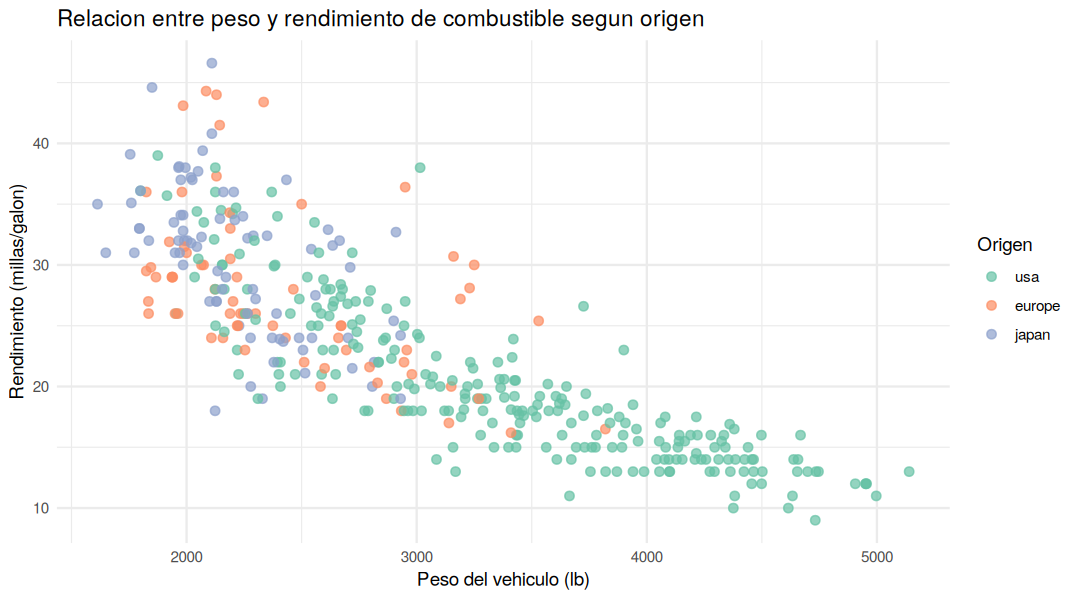

In [ ]:
ggplot(Auto, aes(x = weight, y = mpg, color = origin)) +
  geom_point(alpha = 0.7, size = 2) +
  scale_color_brewer(palette = "Set2") +
  labs(title = "Relacion entre peso y rendimiento de combustible segun origen",
       x = "Peso del vehiculo (lb)", y = "Rendimiento (millas/galon)", color = "Origen") +
  theme_minimal()

cat("Correlacion weight-mpg:", round(cor(Auto$weight, Auto$mpg), 3), "\n")
round(tapply(Auto$weight, Auto$origin, mean), 0)   # peso promedio por origen

**Interpretacion tecnica:**

La correlacion entre el peso y el mpg es -0.83, o sea que es una relacion negativa y fuerte: entre mas pesado es el auto, menos rinde. En el grafico se ve que los autos de USA estan en la zona de mucho peso y poco rendimiento, mientras que los japoneses y europeos estan en la zona de poco peso y mas rendimiento. El peso promedio es 3372 lb en USA, 2433 lb en Europa y 2221 lb en Japon, y eso explica gran parte de por que USA tiene el peor mpg. Aun asi, con pesos parecidos los autos japoneses parecen rendir un poco mas, entonces el origen no se explica solo por el peso. Tambien se nota que la relacion no es del todo una linea recta, sino que se curva un poco. Por ultimo, hay que recordar que una correlacion no significa que una variable cause la otra, y para estar mas seguros se podria hacer una regresion con peso, cilindros y origen.

## Matriz de autoevaluacion

| Criterio | Cumple | Comentario |
|---|---|---|
| El titulo describe que se muestra | Si | Cada grafico dice la variable y la agrupacion |
| Los ejes tienen etiquetas con unidades | Si | Millas/galon, libras, porcentaje y año |
| La escala del eje Y comienza en cero (cuando aplica) | Si | En histograma y barras apiladas empieza en cero. En boxplots y dispersion no aplica |
| El uso del color es informativo | Si | El color representa el origen o los cilindros |
| Se incluye leyenda cuando hay varios grupos | Si | Esta en los graficos con origen o cilindros |
| No hay chartjunk | Si | No se usaron adornos ni graficos 3D |
| El tipo de grafico corresponde a las variables | Si | Histograma y ojiva, boxplots, barras apiladas, mapa de calor y dispersion |